In [3]:

import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
# from sklearn import preprocessing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [4]:
# Depickle
pickle_in = open("data/train.pkl", "rb")
result = pickle.load(pickle_in)

In [5]:
# Convert to numpy array and display the first 5 elements
train_set_full = np.array(result)
train_set_full[:5]

array([[ 2.74276567e+01,  3.33578295e+03],
       [-4.96183456e+00,  2.64740265e+03],
       [-2.78611955e+01,  5.20733695e+02],
       [-1.53463398e+01,  3.51892491e+03],
       [ 2.86732690e+00, -3.21770068e+03]])

In [6]:
# Shuffle the dataset
np.random.shuffle(train_set_full)
train_set_full

array([[ 8.61284568e-01,  8.84717509e+02],
       [ 3.11631328e+01,  7.59229320e+03],
       [-1.39753023e+01,  1.17945470e+03],
       ...,
       [ 7.37749507e+00, -3.12221549e+03],
       [-2.58907520e+01,  2.82101919e+01],
       [-1.33585968e+01,  5.02157677e+03]])

In [7]:
# Separate the dataset
num_datasets = 16
train_sets = np.split(train_set_full, num_datasets)
train_sets[0][:3]

array([[ 8.61284568e-01,  8.84717509e+02],
       [ 3.11631328e+01,  7.59229320e+03],
       [-1.39753023e+01,  1.17945470e+03]])

In [15]:
# Linear regression algorithm
linreg = LinearRegression()

# Scaler
scale = StandardScaler()
poly = PolynomialFeatures(degree=3)


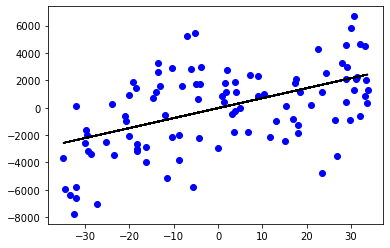

R^2 Value:  0.23834295320023913


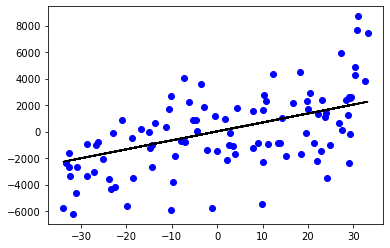

R^2 Value:  0.2290158545640959


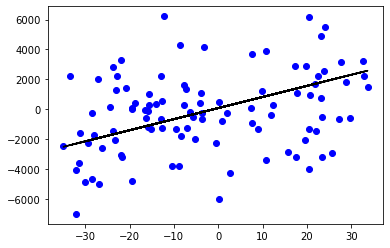

R^2 Value:  0.2166200182071938


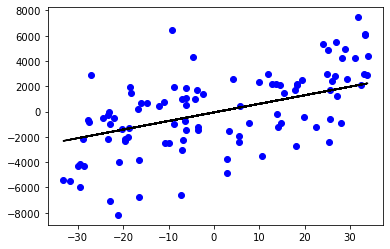

R^2 Value:  0.23949366344246925


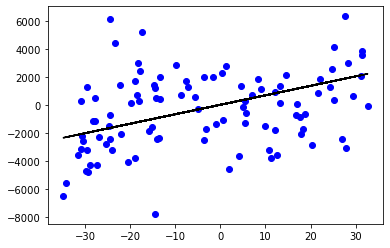

R^2 Value:  0.19304701086011022


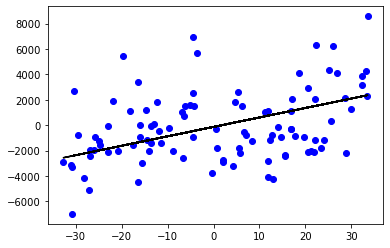

R^2 Value:  0.2177112489122498


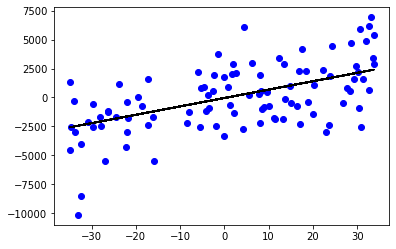

R^2 Value:  0.2667692344467726


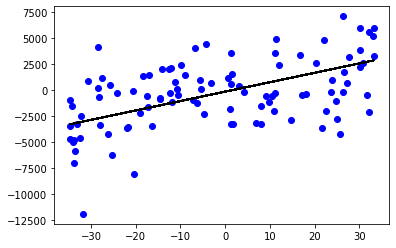

R^2 Value:  0.3154465326505185


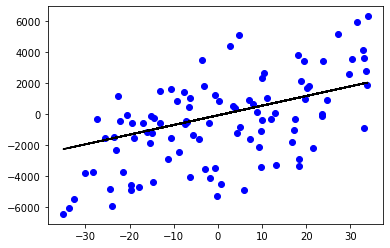

R^2 Value:  0.2138110362565936


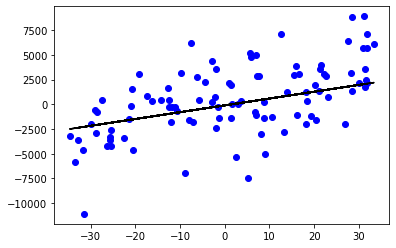

R^2 Value:  0.23218032977055392


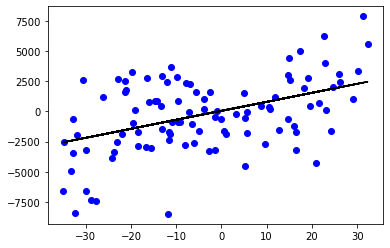

R^2 Value:  0.24544666220898392


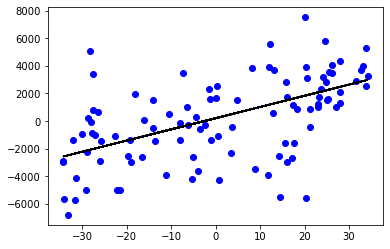

R^2 Value:  0.25989762874012734


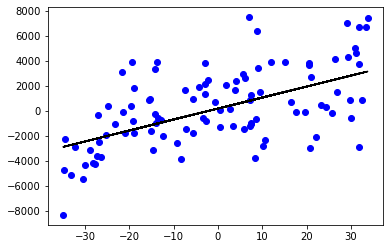

R^2 Value:  0.32416944159723404


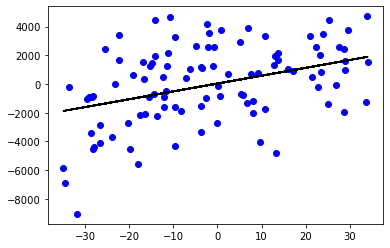

R^2 Value:  0.15586005820906723


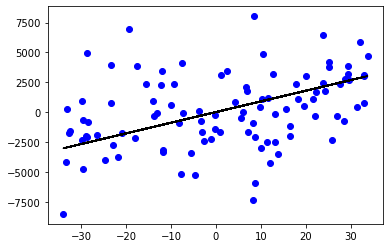

R^2 Value:  0.27527366495222205


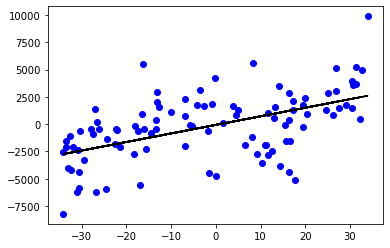

R^2 Value:  0.2874547733713547


In [17]:
for train_set in train_sets:
    # Separate the feature(s) and labels
    X = train_set[:, 0]
    y = train_set[:, 1]
    
    # Convert 1d array to 2d array (train_test_split requires X to be 2 dimensional)
    X = np.reshape(X, (len(X), 1))
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model = linreg.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # Plot graph
    plt.scatter(X_test, y_test, color='blue')
    plt.plot(X_test, predictions, color='black')
    plt.show()
    
    # Accuracy of the model
    print("R^2 Value: ", linreg.score(X, y))